In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('data/gaiadr3_color_mag_2.csv').dropna()
data['Abs_mag'] = data['phot_g_mean_mag'] - 5*np.log10(data['distance_gspphot'])+5
print(f"Before cuts: {data.shape[0]:,}")

# Cuts as described in eq. (11) of Lindegren et al. 
# (https://arxiv.org/abs/1804.09366)
def gamma(g_mag):
    gammas=[]
    val=10**(0.2*(g_mag-18))
    for i in val: gammas.append(np.max([1, i]))
    return np.array(gammas)
data = data.where(
    (data['Abs_mag']<=21.0) &
    (data['visibility_periods_used']>=6) &
    (data['astrometric_sigma5d_max']<=1.2*gamma(data['phot_g_mean_mag']))
).dropna()
print(f"After cuts: {data.shape[0]:,}")


# Color and mag cuts not to be included in cut count. Only matters for plotting purposes
color_cuts=(1.8, 3.5)
mag_cuts=(8, 12)
data = data.where(
    (data['bp_rp']>color_cuts[0]) & (data['bp_rp']<color_cuts[1]) &
    (data['Abs_mag']>mag_cuts[0]) & (data['Abs_mag']<mag_cuts[1])
).dropna()

Before cuts: 118,077
After cuts: 118,049


In [4]:
data

,Unnamed: 0,bp_rp,phot_g_mean_mag,distance_gspphot,visibility_periods_used,astrometric_sigma5d_max,astrometric_excess_noise,astrometric_matched_transits,Abs_mag
0,3.0,2.067990,12.994784,67.6317,14.0,0.026815,0.067658,23.0,8.844032
2,6.0,2.581406,14.860165,95.0371,14.0,0.045501,0.079192,25.0,9.970699
4,10.0,3.079997,17.010885,103.7243,16.0,0.130996,0.339846,24.0,11.931482
6,13.0,2.697027,15.795670,100.6622,13.0,0.080621,0.118216,20.0,10.781338
8,15.0,2.457635,14.886254,93.8637,14.0,0.049360,0.000000,22.0,10.023766
...,...,...,...,...,...,...,...,...,...
118060,574477.0,2.871491,15.895464,92.5364,17.0,0.077158,0.000000,55.0,11.063901
118062,574480.0,2.863453,15.554683,99.5109,17.0,0.068342,0.000000,41.0,10.565330
118070,574505.0,2.591401,15.468045,102.2010,15.0,0.064240,0.096138,25.0,10.420769
118072,574512.0,3.001492,16.474222,99.3288,19.0,0.085703,0.000000,63.0,11.488846


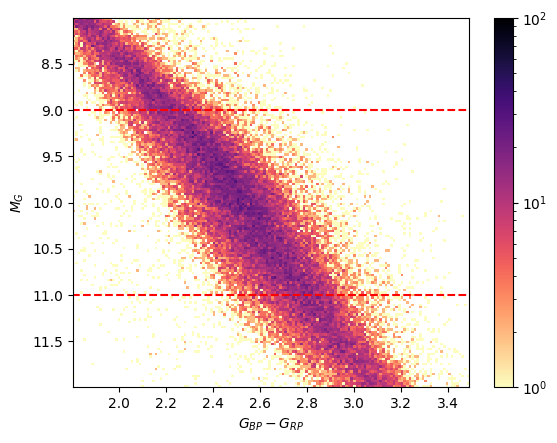

In [5]:
from matplotlib.colors import LogNorm
from matplotlib import colormaps 
fig, ax = plt.subplots()

cmap = colormaps['magma'].reversed()

_, _, _, h = ax.hist2d(data['bp_rp'], data['Abs_mag'], bins=150, cmap=cmap, norm=LogNorm(vmin=1e0, vmax=1e2))#, vmin=0, vmax=10)
ax.plot([color_cuts[0], color_cuts[1]], [9,9], 'r--')
ax.plot([color_cuts[0], color_cuts[1]], [11,11], 'r--')
ax.invert_yaxis()

ax.set(
    xlabel=r'$G_{BP} - G_{RP}$',
    ylabel=r'$M_G$'
)

fig.colorbar(h)
plt.show()

In [6]:
import read_mist_models as read_mist_models
m1 = read_mist_models.ISOCMD('data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_m0.25_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd')

Reading in: data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_m0.25_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd


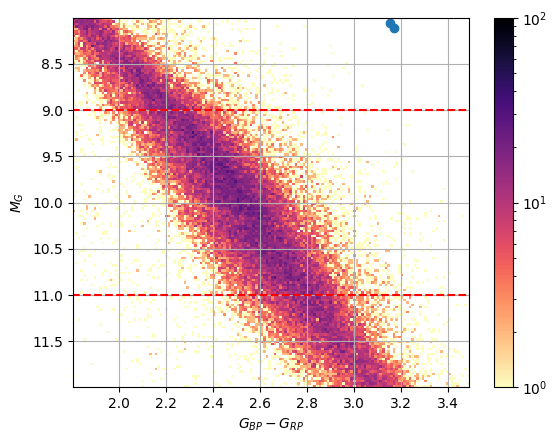

In [7]:
fig, ax = plt.subplots()

cmap = colormaps['magma'].reversed()

_, _, _, h = ax.hist2d(data['bp_rp'], data['Abs_mag'], bins=150, cmap=cmap, norm=LogNorm(vmin=1e0, vmax=1e2))#, vmin=0, vmax=10)
ax.plot([color_cuts[0], color_cuts[1]], [9,9], 'r--')
ax.plot([color_cuts[0], color_cuts[1]], [11,11], 'r--')
ax.invert_yaxis()

ax.set(
    xlabel=r'$G_{BP} - G_{RP}$',
    ylabel=r'$M_G$'
)

fig.colorbar(h)


age_idx = m1.age_index(5)
cat = m1.isocmds[age_idx]

mag = cat['Gaia_G_DR2Rev']
color = cat['Gaia_BP_DR2Rev'] - cat['Gaia_RP_DR2Rev']

mask = (color>1.8) & (color<3.5) & (mag>8) & (mag<12)
mag = mag[mask]
color = color[mask]

ax.scatter(color, mag)


ax.grid()

Reading in: data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd


ValueError: no field of name log_R

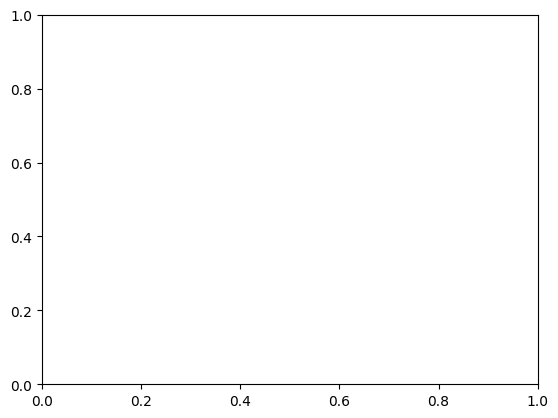

In [65]:
iso = read_mist_models.ISOCMD('data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd')
iso_age = iso.age_index(5)
iso_cmd = iso.isocmds[iso_age]

fig, ax = plt.subplots()

ax.plot(iso_cmd['star_mass'], iso_cmd['log_R'])

Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00034M.track.eep


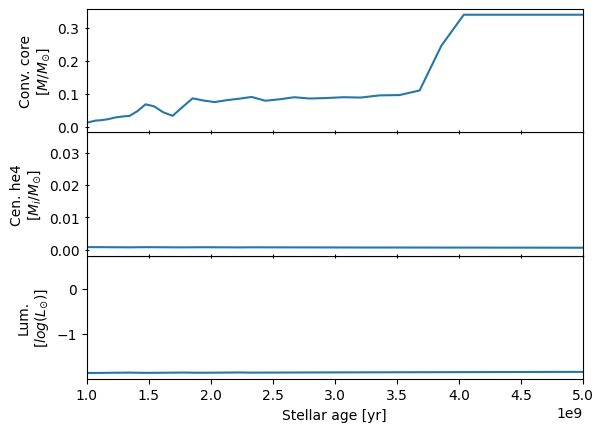

In [28]:
m032 = read_mist_models.EEP('data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00034M.track.eep').eeps

m032 = m032[m032['phase']<2]

fig = plt.figure()
ax3 = fig.add_subplot(3, 1, 3)
ax2 = fig.add_subplot(3, 1, 2)
ax = fig.add_subplot(3, 1, 1)

com_opt = {'xlim':(1e9,5e9)}
ax.set(**com_opt, ylabel='Conv. core\n'+r'$[M/M_{\odot}]$')
ax2.set(**com_opt, ylabel='Cen. he4\n'+r'$[M_i/M_{\odot}]$')#, ylim=(0,0.3))
ax3.set(**com_opt, ylabel='Lum.\n'+r'$[log (L_{\odot})]$', xlabel=f'Stellar age [yr]')

ax.set_xticks(ax2.get_xticks()[1:], labels=[])
ax.tick_params(direction='inout')
ax2.set_xticks(ax3.get_xticks()[1:], labels=[])
ax2.tick_params(direction='inout')
fig.subplots_adjust(hspace=0.0)

ax.plot(m032['star_age'], m032['mass_conv_core'])
# ax.plot(m03['star_age'], m03['conv env top mass'])
ax2.plot(m032['star_age'], m032['log_R']**10)
ax3.plot(m032['star_age'], m032['log_L'])

plt.show()

Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00030M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00032M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00034M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00036M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00038M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00040M.track.eep


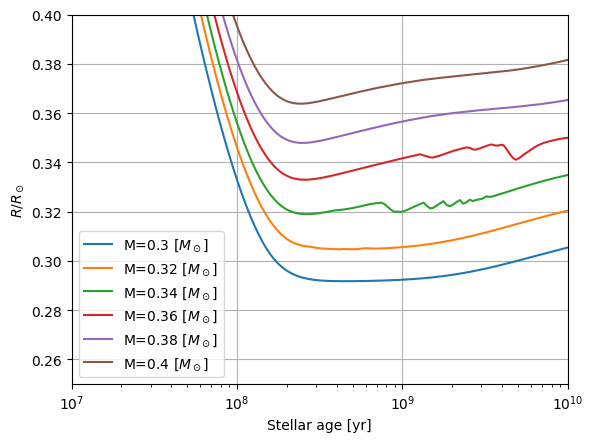

In [82]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

masses = [0.3, 0.32, 0.34, 0.36, 0.38, 0.40]
path = 'data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/'
for i in masses:
    model = read_mist_models.EEP(f'data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/000{int(i*100)}M.track.eep').eeps
    model = model[model['phase']<2]
    
    ax.plot(model['star_age'], 10**model['log_R'], label=fr'M={i} $[M_\odot]$')

ax.set(xlim=(1e7,1e10), ylim=(0.25,0.4), xscale='log', xlabel='Stellar age [yr]', ylabel=r'$R/R_\odot$')
ax.legend()
ax.grid()
plt.show()

Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00030M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00032M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00034M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00036M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00038M.track.eep
Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00040M.track.eep


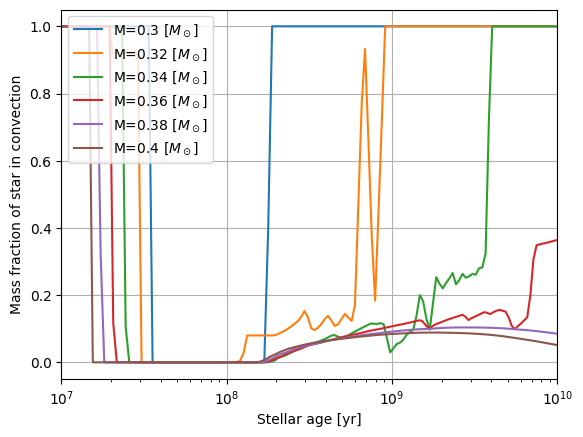

In [81]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

masses = [0.3, 0.32, 0.34, 0.36, 0.38, 0.40]
path = 'data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/'
for i in masses:
    model = read_mist_models.EEP(f'data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/000{int(i*100)}M.track.eep').eeps
    model = model[model['phase']<2]
    
    ax.plot(model['star_age'], model['mass_conv_core']/i, label=fr'M={i} $[M_\odot]$')

ax.set(xlim=(1e7,1e10), xscale='log', xlabel='Stellar age [yr]', ylabel=r'Mass fraction of star in convection')
ax.legend(loc='upper left')
ax.grid()
plt.show()